In [1]:
# Cell 1: Imports (cleaned & minimal)
import os
from pathlib import Path
import math

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Essential SciPy Imports for TPS ---
# cdist is crucial for calculating the r^2 * log(r) kernel matrix efficiently
from scipy.spatial.distance import cdist 
# linalg is needed to solve the weights for the spline
from scipy import linalg
# ndimage is used for map_coordinates (applying the warp)
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


In [2]:
# === CELL 2: Path Setup ===

# Adjust these paths to match your project structure
PROJECT_ROOT = Path("..").resolve()       # notebook is inside /notebooks/
DATA_DIR = PROJECT_ROOT / "data"

DATA_RAW       = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks" 
DATA_PROCESSED = DATA_DIR / "processed"
DATA_ALIGNED   = DATA_PROCESSED / "aligned"

# Add a specific folder for the final caricature outputs
OUTPUT_DIR     = DATA_DIR / "output_caricatures"

# Create directories if missing
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:   ", PROJECT_ROOT)
print("DATA_RAW:       ", DATA_RAW)
print("DATA_LANDMARKS: ", DATA_LANDMARKS)
print("DATA_PROCESSED: ", DATA_PROCESSED)
print("DATA_ALIGNED:   ", DATA_ALIGNED)
print("OUTPUT_DIR:     ", OUTPUT_DIR)
print("\nPath setup complete ✔")

PROJECT_ROOT:    D:\Projects 2025\Caricature Generation
DATA_RAW:        D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS:  D:\Projects 2025\Caricature Generation\data\landmarks
DATA_PROCESSED:  D:\Projects 2025\Caricature Generation\data\processed
DATA_ALIGNED:    D:\Projects 2025\Caricature Generation\data\processed\aligned
OUTPUT_DIR:      D:\Projects 2025\Caricature Generation\data\output_caricatures

Path setup complete ✔


In [3]:
# Cell 3: Landmark loader + visualization helper
def load_landmarks(p):
    """
    Loads landmarks from a .npy file.
    Expects shape (68, 2) or (N, 2).
    """
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr is None or arr.size == 0:
            return None
        arr = np.asarray(arr)
        
        # Ensure correct shape: (N, 2)
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
        return None
    return None

def show_with_landmarks(img_path, lm_path=None, figsize=(6,6)):
    """
    Displays an image. If landmarks are found, overlays them as red dots.
    """
    if not Path(img_path).exists():
        print(f"Image not found: {img_path}")
        return
    # Load image and ensure RGB
    img = np.array(Image.open(img_path).convert('RGB'))
    
    # If landmarks path is provided, try to load and draw
    if lm_path:
        pts = load_landmarks(lm_path)
        if pts is not None:
            for (x, y) in pts:
                # Draw red circles: (255, 0, 0)
                cv2.circle(img, (int(round(x)), int(round(y))), 3, (255, 0, 0), -1)
        else:
            print(f"Warning: Landmarks not found or invalid at {lm_path}")
    # Plot final result once
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    plt.title(Path(img_path).name)
    plt.show()

print("Helper functions defined ✔")

Helper functions defined ✔


In [4]:
# Cell 3.1: Landmark-based face mask helpers

def build_face_mask_from_landmarks(
    img_shape,
    landmarks,
    blur_sigma=8,
    expand_pixels=15
):
    """
    Build a soft face mask from facial landmarks.

    Parameters
    ----------
    img_shape : tuple
        Image shape (H, W, C) or (H, W)
    landmarks : np.ndarray
        Array of shape (N, 2), facial landmarks
    blur_sigma : float
        Gaussian blur sigma for soft edges
    expand_pixels : int
        Morphological expansion to include cheeks/hairline

    Returns
    -------
    mask_soft : np.ndarray
        Float32 mask in range [0, 1], shape (H, W)
    mask_binary : np.ndarray
        Uint8 mask {0,255}, shape (H, W)
    """
    h, w = img_shape[:2]

    # Safety checks
    if landmarks is None or len(landmarks) < 10:
        # Fail-safe: no masking
        mask_binary = np.ones((h, w), dtype=np.uint8) * 255
        mask_soft = mask_binary.astype(np.float32) / 255.0
        return mask_soft, mask_binary

    # Convert landmarks to int
    pts = np.round(landmarks).astype(np.int32)

    # Use convex hull over all landmarks
    hull = cv2.convexHull(pts)

    # Create empty mask
    mask = np.zeros((h, w), dtype=np.uint8)

    # Fill face region
    cv2.fillConvexPoly(mask, hull, 255)

    # Optional expansion to include face boundary / hairline
    if expand_pixels > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (expand_pixels, expand_pixels)
        )
        mask = cv2.dilate(mask, kernel, iterations=1)

    # Convert to soft mask
    mask_soft = gaussian_filter(mask.astype(np.float32) / 255.0, blur_sigma)

    # Clamp numerically
    mask_soft = np.clip(mask_soft, 0.0, 1.0)

    return mask_soft, mask

In [5]:
# Cell 4: Landmark extraction using face_alignment
# Install: pip install face-alignment torch

import face_alignment
from face_alignment import LandmarksType

# ==================== CONFIGURATION ====================
DEMO_LIMIT = 100   # Number of images to process (None = all)
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

# ==================== SETUP ====================
fa = face_alignment.FaceAlignment(
    LandmarksType.TWO_D,
    device=DEVICE,
    flip_input=False
)

LANDROOT = Path(DATA_LANDMARKS)
PREVIEW_DIR = Path(DATA_PROCESSED) / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
FAIL_LOG = Path(DATA_PROCESSED) / "extract_failures.txt"

# NEW: optional mask debug directory
MASK_DEBUG_DIR = Path(DATA_PROCESSED) / "face_masks"
MASK_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def collect_photo_files(root_dir, limit=None):
    """Collect image files with filenames starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_largest_face(landmarks_list):
    """Return index of largest face based on bounding box area."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

def log_failure(filepath, reason):
    """Log failed extractions."""
    with open(FAIL_LOG, "a") as f:
        f.write(f"{filepath}\t{reason}\n")

# ==================== MAIN PROCESSING ====================
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    # Determine output path
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = LANDROOT / rel_path.with_suffix('')
    
    # Skip if already processed
    if out_path.with_suffix('.npy').exists():
        continue
    
    # Load image
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        log_failure(out_path, f"image_load_failed:{e}")
        count_fail += 1
        continue
    
    # Detect landmarks
    try:
        preds = fa.get_landmarks(img)
    except Exception as e:
        log_failure(out_path, f"detection_failed:{e}")
        count_fail += 1
        continue
    
    # Validate results
    if preds is None or len(preds) == 0:
        log_failure(out_path, "no_faces_detected")
        count_fail += 1
        continue
    
    # Select largest detected face
    face_idx = get_largest_face(preds)
    pts = preds[face_idx].astype(np.float32)
    
    if pts.shape[1] != 2:
        log_failure(out_path, "invalid_shape")
        count_fail += 1
        continue

    # ==================== NEW: build face mask from landmarks ====================
    mask_soft, mask_binary = build_face_mask_from_landmarks(
        img_shape=img.shape,
        landmarks=pts,
        blur_sigma=8,
        expand_pixels=15
    )

    # ==================== SAVE RESULTS ====================
    try:
        out_path.parent.mkdir(parents=True, exist_ok=True)

        # Save landmarks
        np.save(str(out_path) + ".npy", pts)
        np.save(
            str(out_path) + "_shape.npy",
            np.array(img.shape[:2], dtype=np.int32)
        )

        # Save landmark preview
        vis = img.copy()
        for (x, y) in pts:
            cv2.circle(vis, (int(x), int(y)), 2, (255, 0, 0), -1)

        preview_path = PREVIEW_DIR / f"{out_path.name}_preview.png"
        Image.fromarray(vis).save(preview_path)

        # NEW: save face mask for debugging (binary)
        mask_path = MASK_DEBUG_DIR / f"{out_path.name}_mask.png"
        Image.fromarray(mask_binary).save(mask_path)

        count_ok += 1

    except Exception as e:
        log_failure(out_path, f"save_failed:{e}")
        count_fail += 1

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print(f"Landmark Extraction Complete")
print(f"{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed:  {count_fail}")
print(f"Failure log: {FAIL_LOG}")
print(f"Previews:    {PREVIEW_DIR}")
print(f"Masks:       {MASK_DEBUG_DIR}")
print(f"{'='*60}")

Found 100 images to process


Extracting landmarks: 100%|███████████████████████████████████████████████████████| 100/100 [00:00<00:00, 16679.81it/s]


Landmark Extraction Complete
✓ Success: 0
✗ Failed:  0
Failure log: D:\Projects 2025\Caricature Generation\data\processed\extract_failures.txt
Previews:    D:\Projects 2025\Caricature Generation\data\processed\previews
Masks:       D:\Projects 2025\Caricature Generation\data\processed\face_masks


Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 100 files. Using 100 shapes with 68 points.
✓ Saved mean normalized shape to: D:\Projects 2025\Caricature Generation\data\processed\aligned\mean_norm_shape.npy


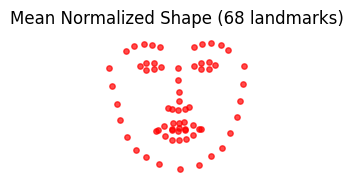

In [6]:
# Cell 5: Build mean normalized shape

# ==================== CONFIGURATION ====================
MIN_LANDMARKS = 5
OUT_MEAN_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
OUT_MEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def bbox_diag(pts):
    """Calculate diagonal length of bounding box for scaling."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

def build_mean_normalized_shape(landmark_root=DATA_LANDMARKS):
    """Build mean shape from all landmark files."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    # Collect all landmark files
    for lm_path in landmark_root.rglob("*.npy"):
        # Skip shape files and non-photo files
        if "_shape" in lm_path.stem:
            continue
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            
            # Validate
            if pts is None or pts.size == 0 or pts.shape[0] < MIN_LANDMARKS:
                continue
            if pts.ndim != 2 or pts.shape[1] != 2:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
            
        except Exception as e:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found! Check your folder path or 'p' prefix filter.")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean shape
    mean_norm_shape = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(OUT_MEAN_PATH, mean_norm_shape)
    print(f"✓ Saved mean normalized shape to: {OUT_MEAN_PATH}")
    
    return mean_norm_shape

# ==================== MAIN EXECUTION ====================
mean_norm = build_mean_normalized_shape()

# ==================== VISUALIZATION ====================
plt.figure(figsize=(2, 2))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=15, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Normalized Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

In [7]:
# Cell 6: Build canonical target_pts and transform helper


OUTPUT_SIZE = (256,256)
TARGET_FACE_SCALE = 0.55
MEAN_NORM_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
TARGET_PTS_PATH = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
TARGET_PTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if MEAN_NORM_PATH.exists():
    mean_norm = np.load(str(MEAN_NORM_PATH))
else:
    try:
        mean_norm
    except NameError:
        raise RuntimeError("Mean normalized shape not found. Run Cell 5 first.")
    else:
        mean_norm = np.asarray(mean_norm)

w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print("Saved target_pts:", TARGET_PTS_PATH)

def estimate_similarity_transform(src_pts, dst_pts, method='ransac'):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    if src.shape[0] < 3:
        raise ValueError("At least 3 points required")
    if method == 'ransac':
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                                 ransacReprojThreshold=3.0, maxIters=2000)
        if M is None:
            M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    else:
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise RuntimeError("estimateAffinePartial2D failed")
    return M# Cell 6: Build canonical target_pts and transform helper


OUTPUT_SIZE = (256,256)
TARGET_FACE_SCALE = 0.55
MEAN_NORM_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
TARGET_PTS_PATH = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
TARGET_PTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if MEAN_NORM_PATH.exists():
    mean_norm = np.load(str(MEAN_NORM_PATH))
else:
    try:
        mean_norm
    except NameError:
        raise RuntimeError("Mean normalized shape not found. Run Cell 5 first.")
    else:
        mean_norm = np.asarray(mean_norm)

w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print("Saved target_pts:", TARGET_PTS_PATH)

def estimate_similarity_transform(src_pts, dst_pts, method='ransac'):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    if src.shape[0] < 3:
        raise ValueError("At least 3 points required")
    if method == 'ransac':
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                                 ransacReprojThreshold=3.0, maxIters=2000)
        if M is None:
            M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    else:
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise RuntimeError("estimateAffinePartial2D failed")
    return M

Saved target_pts: D:\Projects 2025\Caricature Generation\data\processed\aligned\target_pts.npy
Saved target_pts: D:\Projects 2025\Caricature Generation\data\processed\aligned\target_pts.npy


In [9]:
# Cell 7: Robust batch alignment with hair-aware cropping (WITH MASK SUPPORT)

# ==================== CONFIGURATION ====================
OUTPUT_SIZE = (256, 256)
w_out, h_out = OUTPUT_SIZE
DEMO_LIMIT = None
VERBOSE = False
BG_FILL = (30, 30, 30)

ALIGNMENT_METHOD = 'affine'     # 'similarity' or 'affine'
CROP_STRATEGY = 'adaptive'      # 'tight', 'adaptive', or 'loose'
FACE_SCALE = 0.45               # Smaller = more room for hair

# ==================== PATHS ====================
RAWROOT = Path(DATA_RAW)
LANDROOT = Path(DATA_LANDMARKS)
MASK_ROOT = Path(DATA_PROCESSED) / "face_masks"      # from Cell 4
ALIGNED_ROOT = Path(DATA_ALIGNED)
ALIGNED_MASK_ROOT = Path(DATA_PROCESSED) / "aligned_masks"

ALIGNED_ROOT.mkdir(parents=True, exist_ok=True)
ALIGNED_MASK_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def transform_landmarks(pts, M):
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

def collect_photo_files(root_dir, limit=None):
    files = []
    for img_path in root_dir.rglob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)

    width = x_max - x_min
    height = y_max - y_min

    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()
        jaw_bottom = pts[8, 1]
        face_height = jaw_bottom - eyebrow_top
        head_top_estimate = eyebrow_top - face_height * 0.75
    else:
        head_top_estimate = y_min - height * 0.5

    if strategy == 'tight':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
    elif strategy == 'adaptive':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
    else:
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35

    return [
        x_min - pad_x,
        y_min - pad_top,
        x_max + pad_x,
        y_max + pad_bottom
    ]

def estimate_transform_robust(src_pts, dst_pts, method='affine'):
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src_pts, dst_pts, cv2.RANSAC, 5.0)
        else:
            M, _ = cv2.estimateAffinePartial2D(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if M is not None:
            return M
    except:
        pass

    src_center = src_pts.mean(axis=0)
    dst_center = dst_pts.mean(axis=0)
    src_scale = np.sqrt(((src_pts - src_center) ** 2).sum() / len(src_pts))
    dst_scale = np.sqrt(((dst_pts - dst_center) ** 2).sum() / len(dst_pts))
    scale = dst_scale / (src_scale + 1e-8)

    return np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)

def crop_and_align_face(img, pts, mask, output_size, face_scale, crop_strategy):
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size

    x_min, y_min, x_max, y_max = get_face_bbox_with_hair(pts, crop_strategy)
    x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
    x_max, y_max = min(w_img, int(x_max)), min(h_img, int(y_max))

    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_mask = mask[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])

    crop_center = np.array([cropped_img.shape[1]/2, cropped_img.shape[0]/2])
    target_center = np.array([w_out/2, h_out/2])

    # --- FIX: NumPy 2.0 compatibility ---
    face_w = np.ptp(cropped_pts[:, 0])
    face_h = np.ptp(cropped_pts[:, 1])

    scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    target_pts = (cropped_pts - crop_center) * scale + target_center
    M = estimate_transform_robust(cropped_pts, target_pts, ALIGNMENT_METHOD)

    warped_img = cv2.warpAffine(
        cropped_img, M, (w_out, h_out),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=BG_FILL
    )

    warped_mask = cv2.warpAffine(
        cropped_mask, M, (w_out, h_out),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    warped_pts = transform_landmarks(cropped_pts, M)
    return warped_img, warped_mask, warped_pts, M

# ==================== MAIN PROCESSING ====================
raw_images = collect_photo_files(RAWROOT, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")

count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning images with hair + mask"):
    rel_path = img_path.relative_to(RAWROOT)
    stem = rel_path.stem

    lm_path = LANDROOT / rel_path.with_suffix('.npy')
    mask_path = MASK_ROOT / f"{stem}_mask.png"

    out_img = ALIGNED_ROOT / f"{stem}_aligned.png"
    out_lm = ALIGNED_ROOT / f"{stem}_aligned.npy"
    out_M = ALIGNED_ROOT / f"{stem}_affine.npy"
    out_mask = ALIGNED_MASK_ROOT / f"{stem}_aligned_mask.png"

    if not lm_path.exists() or out_img.exists():
        count_skipped += 1
        continue

    img = np.array(Image.open(img_path).convert('RGB'))
    pts = np.load(lm_path).astype(np.float32)

    if mask_path.exists():
        mask = np.array(Image.open(mask_path).convert('L'))
    else:
        mask = np.ones(img.shape[:2], dtype=np.uint8) * 255

    warped_img, warped_mask, warped_pts, M = crop_and_align_face(
        img, pts, mask, OUTPUT_SIZE, FACE_SCALE, CROP_STRATEGY
    )

    Image.fromarray(warped_img).save(out_img)
    Image.fromarray(warped_mask).save(out_mask)
    np.save(out_lm, warped_pts)
    np.save(out_M, M)

    count_ok += 1

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print("Alignment Complete (Hair-aware + Masked)")
print(f"✓ Aligned: {count_ok}")
print(f"○ Skipped: {count_skipped}")
print(f"Output dir: {ALIGNED_ROOT}")
print(f"Mask dir:   {ALIGNED_MASK_ROOT}")
print(f"{'='*60}")

Found 5974 images to align


Aligning images with hair + mask: 100%|██████████████████████████████████████████| 5974/5974 [00:01<00:00, 3868.38it/s]


Alignment Complete (Hair-aware + Masked)
✓ Aligned: 36
○ Skipped: 5938
Output dir: D:\Projects 2025\Caricature Generation\data\processed\aligned
Mask dir:   D:\Projects 2025\Caricature Generation\data\processed\aligned_masks


In [10]:
# Cell 8: Full-image TPS warp with LOCAL + GLOBAL exaggeration control (WITH MASK)

import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import scipy.linalg

# ==================== PARAMETERS ====================
REG = 1e-3
GRID_STEP = 2
FALLOFF_RADIUS_FACTOR = 1.8
FALLOFF_SHARPNESS = 2.0
DEMO_N = None
OUT_SUBDIR = "tps_normalized"
DEBUG = False

LOCAL_EXAGGERATION = 1.25
GLOBAL_EXAGGERATION = 1.60

LOCAL_FEATURE_GROUPS = {
    'left_eyebrow': list(range(17, 22)),
    'right_eyebrow': list(range(22, 27)),
    'nose': list(range(27, 36)),
    'left_eye': list(range(36, 42)),
    'right_eye': list(range(42, 48)),
    'mouth': list(range(48, 68)),
}

ALIGNED_ROOT = Path(DATA_ALIGNED)
MASK_ROOT = Path(DATA_PROCESSED) / "aligned_masks"
OUT_ROOT = Path(DATA_PROCESSED) / OUT_SUBDIR
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== TPS FUNCTIONS ====================
def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-3):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    return coeffs[:N], coeffs[N:]

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

# ==================== EXAGGERATION ====================
def apply_local_exaggeration(pts, local_factor, feature_groups):
    pts_out = pts.copy()
    if local_factor == 1.0:
        return pts_out
    for _, idx in feature_groups.items():
        idx = [i for i in idx if i < len(pts)]
        if not idx:
            continue
        c = pts[idx].mean(axis=0)
        for i in idx:
            pts_out[i] = c + local_factor * (pts[i] - c)
    return pts_out

def apply_global_exaggeration(pts, global_factor):
    if global_factor == 1.0:
        return pts.copy()
    c = pts.mean(axis=0)
    return c + global_factor * (pts - c)

def compute_tps_warp(img, src_pts, dst_pts):
    h, w = img.shape[:2]
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], REG)
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], REG)
    xs = np.arange(w)
    ys = np.arange(h)
    map_x = tps_eval_grid(dst_pts, w_x, a_x, xs, ys)
    map_y = tps_eval_grid(dst_pts, w_y, a_y, xs, ys)
    return map_x.astype(np.float32), map_y.astype(np.float32)

# ==================== MAIN ====================
aligned_imgs = sorted(ALIGNED_ROOT.rglob("*_aligned.png"))
if not aligned_imgs:
    raise RuntimeError("No aligned images found")

aligned_imgs = aligned_imgs if DEMO_N is None else aligned_imgs[:DEMO_N]

print(f"TPS: LOCAL={LOCAL_EXAGGERATION}, GLOBAL={GLOBAL_EXAGGERATION}")

for p in aligned_imgs:
    stem = p.stem.replace("_aligned", "")
    lm_p = ALIGNED_ROOT / f"{stem}_aligned.npy"
    mask_p = MASK_ROOT / f"{stem}_aligned_mask.png"
    out_p = OUT_ROOT / f"{stem}_tps.png"

    if not lm_p.exists() or not mask_p.exists():
        continue

    try:
        img = np.array(Image.open(p).convert("RGB"))
        mask = np.array(Image.open(mask_p).convert("L")).astype(np.float32) / 255.0
        mask_soft = gaussian_filter(mask, sigma=6)
        mask_soft = np.clip(mask_soft, 0.0, 1.0)

        pts = np.load(lm_p).astype(np.float64)

        pts_local = apply_local_exaggeration(pts, LOCAL_EXAGGERATION, LOCAL_FEATURE_GROUPS)
        pts_final = apply_global_exaggeration(pts_local, GLOBAL_EXAGGERATION)

        map_x, map_y = compute_tps_warp(img, pts, pts_final)

        h, w = img.shape[:2]
        id_x, id_y = np.meshgrid(np.arange(w), np.arange(h))

        # FACE-MASK-CONSTRAINED TPS
        final_map_x = mask_soft * map_x + (1 - mask_soft) * id_x
        final_map_y = mask_soft * map_y + (1 - mask_soft) * id_y

        warped = cv2.remap(
            img, final_map_x, final_map_y,
            interpolation=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0,0,0)
        )

        out_p.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(out_p)

    except Exception as e:
        print("Failed:", p.name, e)

print(f"\n✓ TPS outputs saved to: {OUT_ROOT}")

TPS: LOCAL=1.25, GLOBAL=1.6
Failed: P00001_aligned.png name 'gaussian_filter' is not defined
Failed: P00002_aligned.png name 'gaussian_filter' is not defined
Failed: P00003_aligned.png name 'gaussian_filter' is not defined
Failed: P00004_aligned.png name 'gaussian_filter' is not defined
Failed: P00005_aligned.png name 'gaussian_filter' is not defined
Failed: P00006_aligned.png name 'gaussian_filter' is not defined
Failed: P00007_aligned.png name 'gaussian_filter' is not defined
Failed: P00008_aligned.png name 'gaussian_filter' is not defined
Failed: P00009_aligned.png name 'gaussian_filter' is not defined
Failed: P00010_aligned.png name 'gaussian_filter' is not defined
Failed: P00011_aligned.png name 'gaussian_filter' is not defined
Failed: P00012_aligned.png name 'gaussian_filter' is not defined
Failed: P00013_aligned.png name 'gaussian_filter' is not defined
Failed: P00014_aligned.png name 'gaussian_filter' is not defined
Failed: P00015_aligned.png name 'gaussian_filter' is not defin

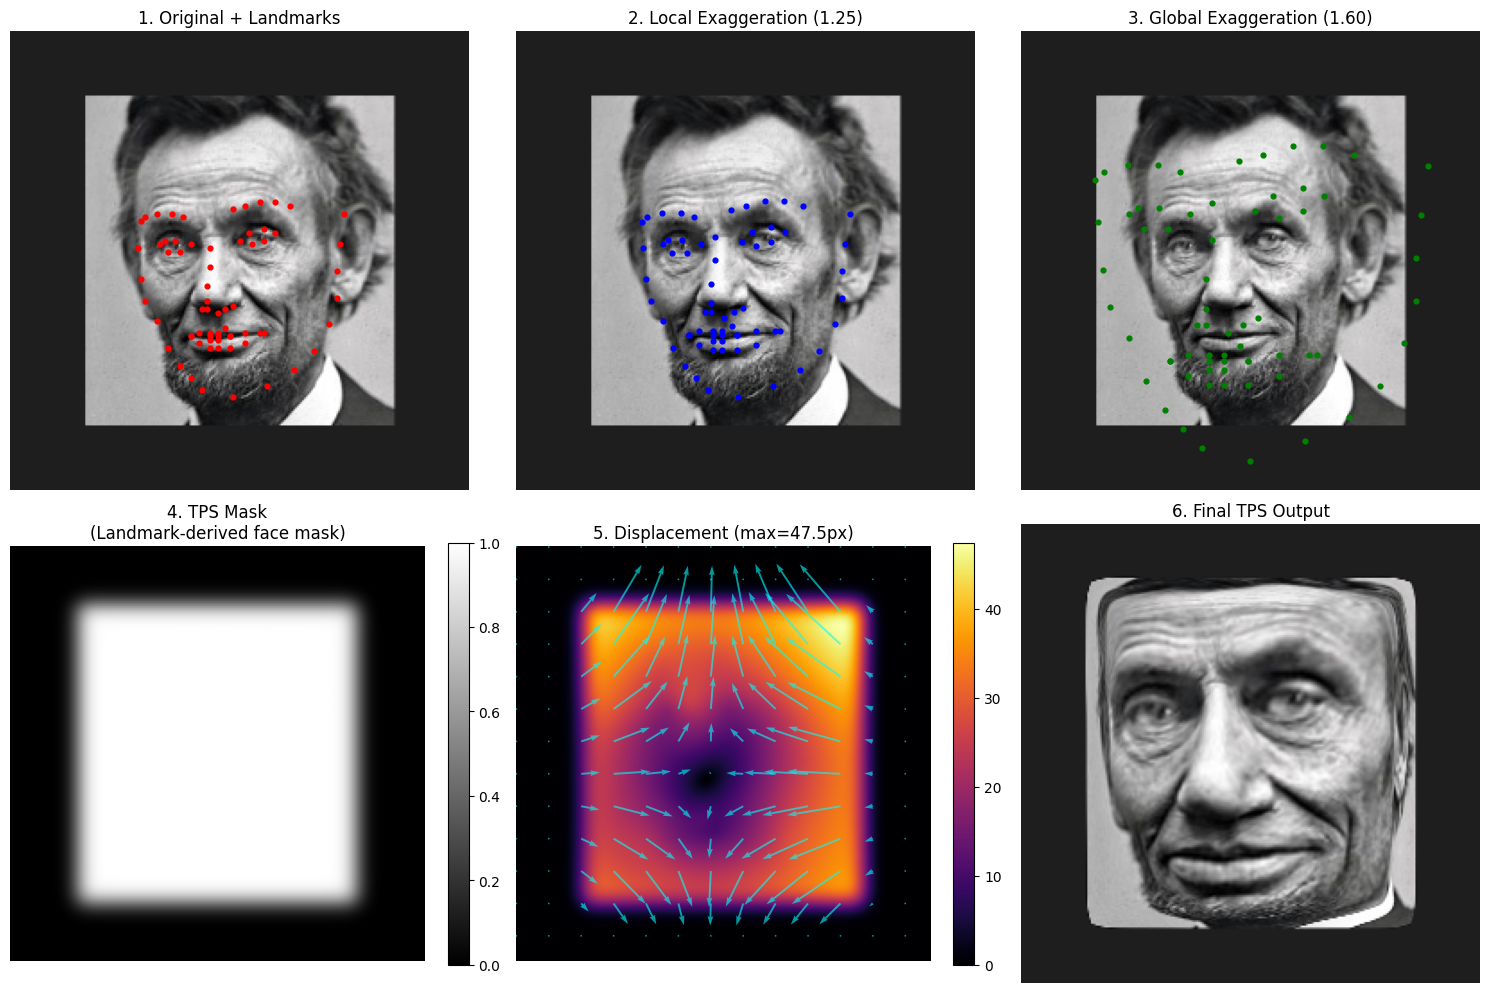


IMAGE: P00001_aligned.png
Local exaggeration:   1.250
Global exaggeration:  1.600
Max displacement:    47.46px
Mean displacement:   13.24px
Pixels affected (>1px): 40190 (61.3%)


In [12]:
# === CELL 10 (FINAL): Visualization & Debug (MASK + Local + Global TPS) ===

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
from scipy.ndimage import gaussian_filter

# ---- User Controls ----
SAMPLE_INDEX = 0
SHOW_ARROWS = True
SHOW_LANDMARKS = True
GRID_STEP = 2

VIZ_MODE = 'full'   # 'full' or 'compact'

# ---- Paths ----
ALIGNED_ROOT = Path(DATA_ALIGNED)
MASK_ROOT = Path(DATA_PROCESSED) / "aligned_masks"
OUT_ROOT = Path(DATA_PROCESSED) / "tps_normalized"

# ---- Load aligned images ----
aligned_imgs = sorted([
    p for p in ALIGNED_ROOT.rglob("*_aligned.png")
    if p.stem.lower().startswith('p')
])

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found. Run alignment first.")

SAMPLE_INDEX = max(0, min(SAMPLE_INDEX, len(aligned_imgs) - 1))
img_path = aligned_imgs[SAMPLE_INDEX]
stem = img_path.stem.replace("_aligned", "")

lm_path = ALIGNED_ROOT / f"{stem}_aligned.npy"
mask_path = MASK_ROOT / f"{stem}_aligned_mask.png"
out_path = OUT_ROOT / f"{stem}_tps.png"

if not lm_path.exists():
    raise RuntimeError(f"Missing landmarks for {img_path.name}")

# ---- Load image & landmarks ----
img = np.array(Image.open(img_path).convert("RGB"))
h, w = img.shape[:2]
src_pts = np.load(lm_path).astype(np.float64)

# ---- Load mask (robust fallback) ----
if mask_path.exists():
    mask = np.array(Image.open(mask_path).convert("L")).astype(np.float32) / 255.0
    mask_soft = gaussian_filter(mask, sigma=6)
    mask_soft = np.clip(mask_soft, 0.0, 1.0)
    mask_note = "Landmark-derived face mask"
else:
    print("⚠ Mask not found – using full-image fallback mask.")
    mask_soft = np.ones((h, w), dtype=np.float32)
    mask_note = "Fallback full-image mask (DEBUG ONLY)"

# ---- Landmark exaggeration ----
pts_local = apply_local_exaggeration(
    src_pts.copy(),
    LOCAL_EXAGGERATION,
    LOCAL_FEATURE_GROUPS
)

dst_pts = apply_global_exaggeration(
    pts_local,
    GLOBAL_EXAGGERATION
)

# ---- TPS solve ----
w_x, a_x = solve_tps(dst_pts, src_pts[:, 0], reg=REG)
w_y, a_y = solve_tps(dst_pts, src_pts[:, 1], reg=REG)

xs = np.arange(w)
ys = np.arange(h)

map_x = tps_eval_grid(dst_pts, w_x, a_x, xs, ys).astype(np.float32)
map_y = tps_eval_grid(dst_pts, w_y, a_y, xs, ys).astype(np.float32)

# ---- Identity grid ----
id_x, id_y = np.meshgrid(xs, ys)

# ---- MASK-CONSTRAINED TPS ----
final_map_x = mask_soft * map_x + (1.0 - mask_soft) * id_x
final_map_y = mask_soft * map_y + (1.0 - mask_soft) * id_y

final_map_x = np.clip(final_map_x, 0, w - 1)
final_map_y = np.clip(final_map_y, 0, h - 1)

# ---- REQUIRED: OpenCV remap expects float32, contiguous ----
final_map_x = np.ascontiguousarray(final_map_x, dtype=np.float32)
final_map_y = np.ascontiguousarray(final_map_y, dtype=np.float32)

warped = cv2.remap(
    img, final_map_x, final_map_y,
    interpolation=cv2.INTER_CUBIC,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0)
)


# ---- Displacement magnitude ----
disp_x = final_map_x - id_x
disp_y = final_map_y - id_y
magnitude = np.sqrt(disp_x**2 + disp_y**2)

# ==================== VISUALIZATION ====================
if VIZ_MODE == 'full':
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax = ax.ravel()

    # 1. Original + landmarks
    ax[0].imshow(img)
    ax[0].set_title("1. Original + Landmarks")
    if SHOW_LANDMARKS:
        ax[0].scatter(src_pts[:,0], src_pts[:,1], c='red', s=12)
    ax[0].axis('off')

    # 2. Local exaggeration
    ax[1].imshow(img)
    ax[1].set_title(f"2. Local Exaggeration ({LOCAL_EXAGGERATION:.2f})")
    if SHOW_LANDMARKS:
        ax[1].scatter(pts_local[:,0], pts_local[:,1], c='blue', s=12)
    ax[1].axis('off')

    # 3. Global exaggeration
    ax[2].imshow(img)
    ax[2].set_title(f"3. Global Exaggeration ({GLOBAL_EXAGGERATION:.2f})")
    if SHOW_LANDMARKS:
        ax[2].scatter(dst_pts[:,0], dst_pts[:,1], c='green', s=12)
    ax[2].axis('off')

    # 4. Face mask
    im4 = ax[3].imshow(mask_soft, cmap='gray', vmin=0, vmax=1)
    ax[3].set_title(f"4. TPS Mask\n({mask_note})")
    ax[3].axis('off')
    plt.colorbar(im4, ax=ax[3], fraction=0.046)

    # 5. Distortion heatmap
    im5 = ax[4].imshow(magnitude, cmap='inferno')
    ax[4].set_title(f"5. Displacement (max={magnitude.max():.1f}px)")
    if SHOW_ARROWS:
        step = 20
        ax[4].quiver(
            id_x[::step, ::step], id_y[::step, ::step],
            disp_x[::step, ::step], disp_y[::step, ::step],
            color='cyan', alpha=0.6, scale=1, scale_units='xy'
        )
    ax[4].axis('off')
    plt.colorbar(im5, ax=ax[4], fraction=0.046)

    # 6. Final result
    ax[5].imshow(warped)
    ax[5].set_title("6. Final TPS Output")
    ax[5].axis('off')

else:
    fig, ax = plt.subplots(1, 3, figsize=(14, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[1].imshow(mask_soft, cmap='gray')
    ax[1].set_title("TPS Mask")
    ax[2].imshow(warped)
    ax[2].set_title("Final TPS")
    for a in ax:
        a.axis('off')

plt.tight_layout()
plt.show()

# ==================== STATS ====================
print("\n" + "="*60)
print(f"IMAGE: {img_path.name}")
print("="*60)
print(f"Local exaggeration:   {LOCAL_EXAGGERATION:.3f}")
print(f"Global exaggeration:  {GLOBAL_EXAGGERATION:.3f}")
print(f"Max displacement:    {magnitude.max():.2f}px")
print(f"Mean displacement:   {magnitude.mean():.2f}px")
print(f"Pixels affected (>1px): {(magnitude > 1.0).sum()} "
      f"({100*(magnitude > 1.0).sum()/(h*w):.1f}%)")
print("="*60)